In [1]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-07 19:42:13--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-03-07 19:42:13 (11.0 MB/s) - ‘names.txt’ saved [228145/228145]



In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# Set up vocab and mapping
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [5]:
def build_dataset(words):
  block_size = 3    # context length: how many characters do we take to predict the next one?
  X, Y = [], []

  # we want X to be each of the first three characters, then Y to be the next character
  for word in words:

    # since 0 represents the dot, basically we initialize it to allow padding
    # context is the numeric repr of the character we're processing at hand
    context = [0] * block_size

    for ch in word + '.':
      ix = stoi[ch]

      X.append(context)
      Y.append(ix)

      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)

  return X, Y

In [6]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# split
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

## Fix 1: Initialization Problems Leading to High Initial Loss (And Unproductive Training)

Originally, before fixing, the initial loss is way higher than it is supposed to. For example:

```
      0/ 200000: 25.4621
  10000/ 200000: 2.9909
  20000/ 200000: 2.5111
  30000/ 200000: 2.7294
  40000/ 200000: 2.4408
```

If we truly thought about the probabilities, we'll notice that the initial loss should be close to around the negative log probability of 1/27, which is $-ln(1/27) \approx 3.296$. So the initial loss should've been around 3.3, but because all the original weights were randomly initialized and then compunded together through multiple operations, those logits and thus probabitilities come out to be largely wrong. That makes the loss higher, if the model are confidently wrong in it probabitilies.

On the other hand, if the logits are closer to 0, then the loss would be lower. This is because of our one-hot encoding of the characters. By comparing the logits to the answers, each answer should consist of all 0s but one 1, signifying the character that the answer represents.

Here's a visual:

$$logits = [-5.4, 4.2, 20.78, ..., -11.16]$$
$$Y = [0, 1, 0, ..., 0]$$

So of course, if the logits are mostly different from the answer, then the loss will be high. So far, this has kind of worked out for us. We've been seeing this kind of "hockey stick" appearance where the loss is really high in the beginning, and then in the first several iterations, the model is trying to squash down the weights. However, we'd like to not waste the first several iterations of the training process--just one of those optimizations :)

The fix is as follows:
- Since it's the logits that predict the results, we'll want to adjust the initialization of W2 and b2.
- In particular, we'll want to scale W2 down by a lot
- And set b2 to 0.

We usually don't want to set weights to 0 because of the vanishing gradient problem, where eventually all gradients just become 0. See the section Problem 2 below.

In [7]:
# Set up hyperparameters
vocab_size = len(chars) + 1
block_size = 3
n_embed = 11
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed)             , generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden) , generator=g)
b1 = torch.randn((1, n_hidden)                    , generator=g)
W2 = torch.randn((n_hidden, vocab_size)           , generator=g) * 0.01   # fix problem 1
b2 = torch.randn((1, vocab_size)                  , generator=g) * 0      # fix problem 1
parameters = [C, W1, b1, W2, b2]

print(f"num parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

num parameters: 12524


In [8]:
# Training
lossi = []
batch_size = 32
initial_lr = 0.1
iterations = 200000

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))

  # forward pass
  emb = C[Xtr[ix]]
  pre_h = emb.view((-1, n_embed * block_size)) @ W1 + b1
  h = torch.tanh(pre_h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = initial_lr if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # Note: Uncomment below if you'd like to visualize h below
  # break

      0/ 200000: 22.3320
  10000/ 200000: 2.5561
  20000/ 200000: 2.8508
  30000/ 200000: 2.1364
  40000/ 200000: 2.5277
  50000/ 200000: 2.1755
  60000/ 200000: 2.6161
  70000/ 200000: 2.0997
  80000/ 200000: 2.3630
  90000/ 200000: 1.7716
 100000/ 200000: 2.5200
 110000/ 200000: 2.2192
 120000/ 200000: 2.2317
 130000/ 200000: 1.9535
 140000/ 200000: 2.5282
 150000/ 200000: 2.2472
 160000/ 200000: 2.4386
 170000/ 200000: 2.0480
 180000/ 200000: 1.9752
 190000/ 200000: 1.9421


In [9]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'val': (Xval, Yval),
      'test': (Xte, Yte),
  }[split]
  emb = C[x]  # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
  h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
  logits = h @ W2 + b2  # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

In [10]:
split_loss('train')
split_loss('val')

train 2.108337163925171
val 2.153677463531494


## Problem 2: Vanishing Gradient

We can visualize the histogram of the `h` matrix (after applying tanh) to see what's up with it. If we do, we'll notice many of its values are close to or exactly 1 or -1.

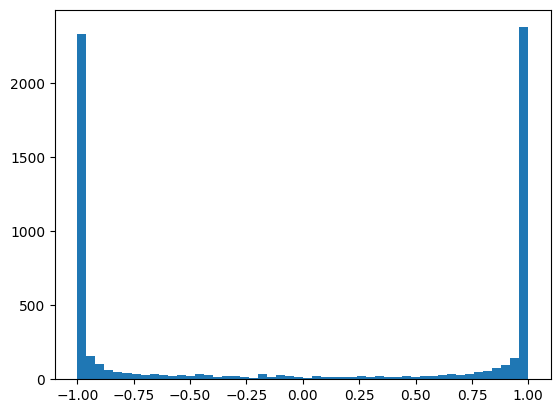

In [ ]:
plt.hist(h.view(-1).tolist(), 50);

We can look at the cause of this. If we look at the histogram of the data passed into tanh, the `pre_h` (which is `embcat @ W1 + b1`), then we see that most values are outside of the -1 and 1 range, which makes tanh just gather all of them up and cap them at -1 and 1, instead of them being distributed evenly between -1 and 1.

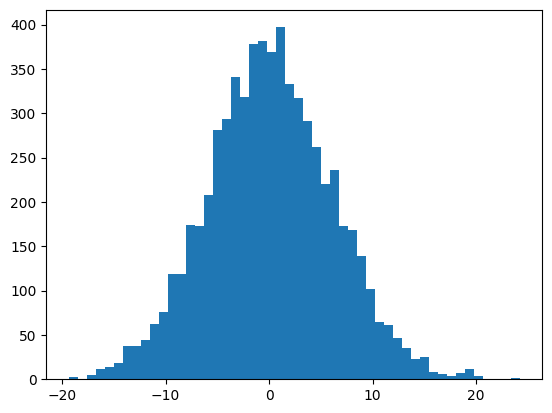

In [ ]:
plt.hist(pre_h.view(-1).tolist(), 50);

This becomes a problem of **vanishing gradients**. That means when we backprop, there's a chance that the gradient will become 0, depending on what our loss function looks like. In our case, because we're using tanh, the gradient is
$$(1 - t^2) \cdot grad$$

When t is -1 or 1, that first term will become 0. This means that if most of our h is 1, we'll have mostly a gradient of 0, which doesn't help with improving the model.

This can generally happen with any function that has a flat region, like even the sigmoid or the ReLU functions. The main point is to make sure that neurons fire with some examples. If a neuron never fires with any examples, then it's called a **dead neuron**. No examples will ever activate it (its activation is never high enough), and thus the gradient will never be anything but 0, which does not change its weights. It will never learn that way.

This can also happen during the optimization process, where if the learning rate is too high, it might "knock" the neuron weights back so much that their gradients end up in the flat regions, never to recover to see the light of day.

We can check this with a plot:

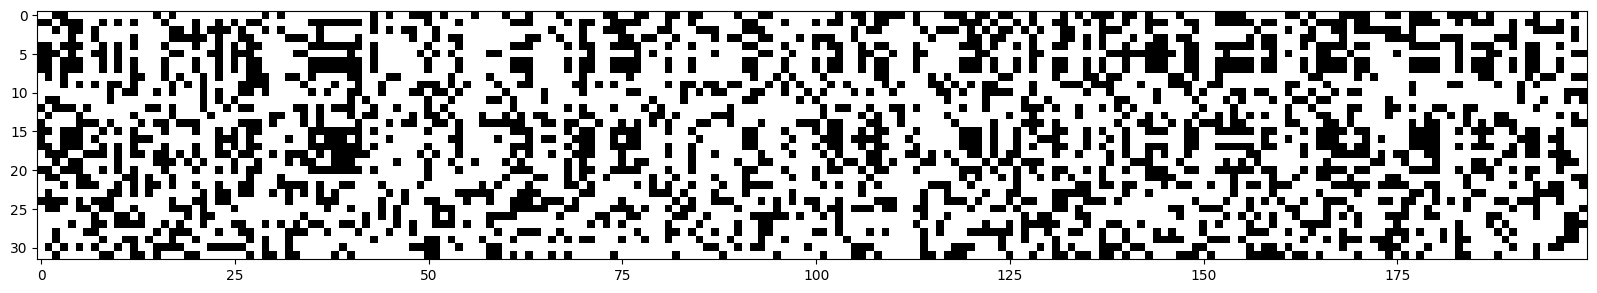

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In the plot above, each white cell represents that it's either a -1 or a 1 (absolute value is 1). If there is ever a completely white column, that means it's always firing either a -1 or a 1. That's a dead neuron. Fortunately, we don't see any of that above.

The graphs below represent what happens when we scale the weights and bias down (W1, b1) by a lot:

In [ ]:
# Set up hyperparameters
vocab_size = len(chars) + 1
block_size = 3
n_embed = 11
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed)             , generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden) , generator=g) * 0.2    # fix problem 2
b1 = torch.randn((1, n_hidden)                    , generator=g) * 0.01   # fix problem 2
W2 = torch.randn((n_hidden, vocab_size)           , generator=g) * 0.01   # fix problem 1
b2 = torch.randn((1, vocab_size)                  , generator=g) * 0      # fix problem 1
parameters = [C, W1, b1, W2, b2]

print(f"num parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

num parameters: 12524


In [ ]:
# Training
lossi = []
batch_size = 32
initial_lr = 0.1
iterations = 200000

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))

  # forward pass
  emb = C[Xtr[ix]]
  pre_h = emb.view((-1, n_embed * block_size)) @ W1 + b1
  h = torch.tanh(pre_h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = initial_lr if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # Note: Uncomment below if you'd like to visualize h below
  # break

      0/ 200000: 3.3269
  10000/ 200000: 2.1018
  20000/ 200000: 2.1105
  30000/ 200000: 2.3289
  40000/ 200000: 2.4654
  50000/ 200000: 2.1531
  60000/ 200000: 1.8903
  70000/ 200000: 2.1058
  80000/ 200000: 2.1354
  90000/ 200000: 2.0716
 100000/ 200000: 2.3498
 110000/ 200000: 2.0522
 120000/ 200000: 1.9769
 130000/ 200000: 2.0393
 140000/ 200000: 1.7642
 150000/ 200000: 2.1508
 160000/ 200000: 1.6037
 170000/ 200000: 1.8728
 180000/ 200000: 1.9932
 190000/ 200000: 2.1704


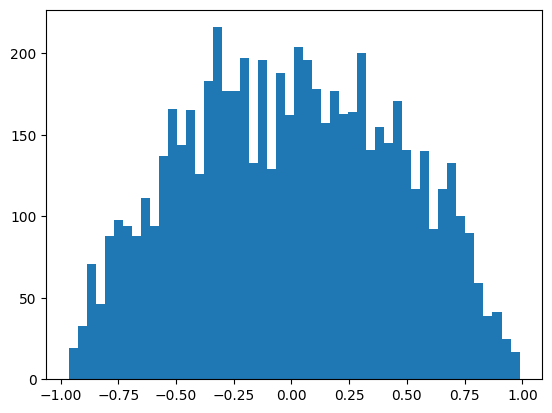

In [ ]:
plt.hist(h.view(-1).tolist(), 50);

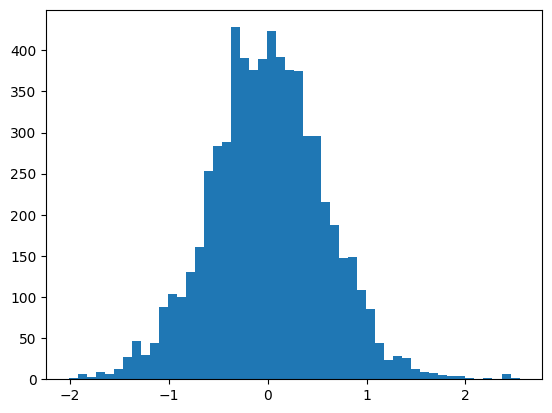

In [ ]:
plt.hist(pre_h.view(-1).tolist(), 50);

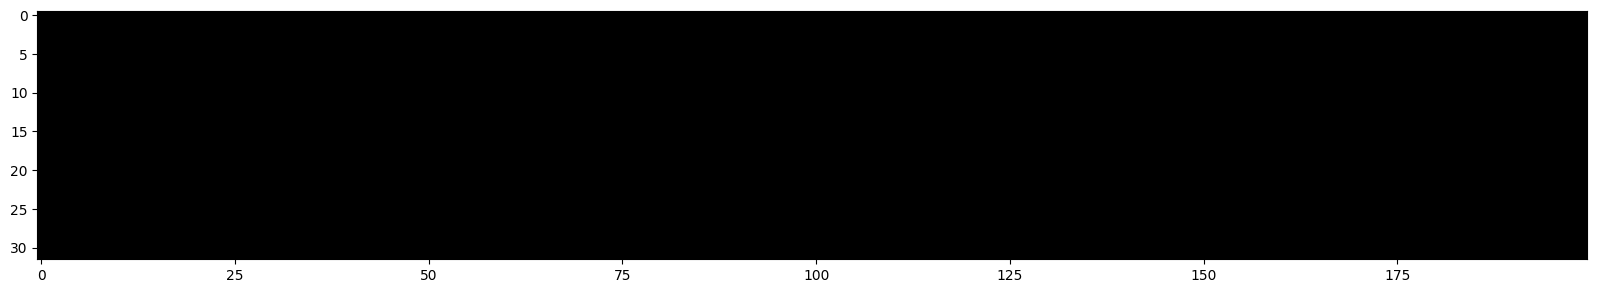

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

As seen above, by scaling down the weights and biases toward 0, there are less neurons that have an extreme activation due to higher weights and biases, and thus can be trained better.

In [ ]:
split_loss('train')
split_loss('val')

train 2.0329463481903076
val 2.100602388381958


## Importance of Optimizing Initializations

Just by optimizing the initializations, our loss has gone down:

Original:
| Dataset | Loss |
| -- | -- |
| train | 2.108337163925171 |
|  val  | 2.153677463531494 |

After fixing wildly random values:
| Dataset | Loss |
| -- | -- |
| train | 2.064493179321289 |
|  val  | 2.130030870437622 |

After fixing the vanishing gradient problem:
| Dataset | Loss |
| -- | -- |
| train | 2.0329463481903076 |
|  val  | 2.100602388381958 |


This goes to show how important these little optimizations can be, especially later down the line with 50-layer neural networks--these little changes add up.

## Kaiming Init
### How to Know What Factor to Scale the Weights By?

Just before we continue to see our victorious new sampling, let's take a look at how we should choose the scale factor.

Instead of just guessing and checking, we can follow the Kaiming Init principle. [Kaiming et al.](https://arxiv.org/pdf/1502.01852) discovered these factors for the different functions.

We can look at a motivating example:

tensor(0.0116) tensor(0.9910)
tensor(0.0008) tensor(3.0330)


(array([1.49591622e-05, 2.24387434e-05, 9.72345545e-05, 7.47958112e-05,
        1.27152879e-04, 2.54305758e-04, 4.11376961e-04, 7.10560206e-04,
        1.03966178e-03, 1.43607957e-03, 2.31867015e-03, 3.94921883e-03,
        6.10333819e-03, 9.28216017e-03, 1.40316942e-02, 2.07633172e-02,
        3.01202732e-02, 4.27233673e-02, 5.78246416e-02, 7.75557766e-02,
        9.74813807e-02, 1.15821314e-01, 1.32949554e-01, 1.41992368e-01,
        1.39711096e-01, 1.29606182e-01, 1.16531874e-01, 9.54768530e-02,
        7.49753211e-02, 5.57827160e-02, 4.05468092e-02, 2.90880910e-02,
        2.03968177e-02, 1.31341444e-02, 8.32477378e-03, 5.52741045e-03,
        3.19378114e-03, 2.40842512e-03, 1.59315078e-03, 9.05029315e-04,
        6.50723557e-04, 3.21621988e-04, 2.61785339e-04, 1.04714136e-04,
        9.72345545e-05, 8.22753923e-05, 4.48774867e-05, 2.24387434e-05,
        7.47958112e-06, 1.49591622e-05]),
 array([-16.00121307, -15.33272644, -14.66423981, -13.99575317,
        -13.32726654, -12.6587

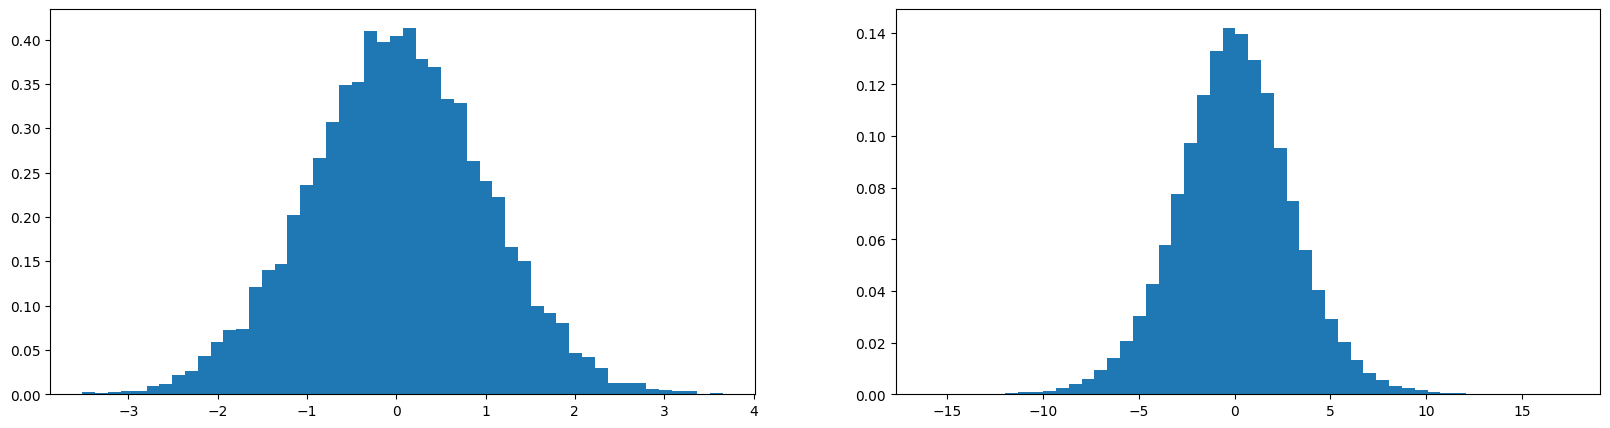

In [ ]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

As we can see, the graph on the left represents the original input mean and standard deviation, which is between around -3 to 3. The graph on the right depict those of the result, which is `x @ w`. The standard deviation here is much larger, from -10 to 10. You can also see in the text output above the standard deviation in x is 1, but that in y is 3.

Because of this behavior, we want to readjust so that the standard deviation of y is 1. We can do so by multiplying by:

$$\sqrt{fan\_in}$$

where $fan\_in$ is the number of inputs (in this case, for w, that's 10). Notice how I said w, not y. That's because essentially, since y is calculated from multiplying x and w, we need to rescale w. Since w has a fan in of 10, we can multiply it by $\sqrt{10}$.

tensor(-0.0066) tensor(1.0163)
tensor(0.0014) tensor(1.0174)


(array([4.23502136e-05, 2.11751068e-05, 2.11751068e-05, 2.11751068e-05,
        8.47004272e-05, 2.96451495e-04, 3.81151922e-04, 6.77603417e-04,
        1.10110555e-03, 1.73635876e-03, 2.77393899e-03, 4.99732520e-03,
        7.64421355e-03, 1.28744649e-02, 2.02010519e-02, 3.22496876e-02,
        4.84486443e-02, 7.37105467e-02, 1.07294266e-01, 1.53350123e-01,
        2.02878698e-01, 2.64434734e-01, 3.33296181e-01, 3.82464779e-01,
        4.24687942e-01, 4.21723427e-01, 4.01395324e-01, 3.37086525e-01,
        2.77626825e-01, 2.19352931e-01, 1.59025052e-01, 1.14260876e-01,
        7.93643003e-02, 5.50552777e-02, 3.55530043e-02, 2.25726638e-02,
        1.47590494e-02, 8.59709336e-03, 5.50552777e-03, 2.87981452e-03,
        1.67283344e-03, 1.41873216e-03, 5.71727883e-04, 2.75276388e-04,
        3.17626602e-04, 8.47004272e-05, 6.35253204e-05, 1.05875534e-04,
        2.11751068e-05, 4.23502136e-05]),
 array([-5.92595482, -5.6898285 , -5.45370218, -5.21757586, -4.98144955,
        -4.74532323, 

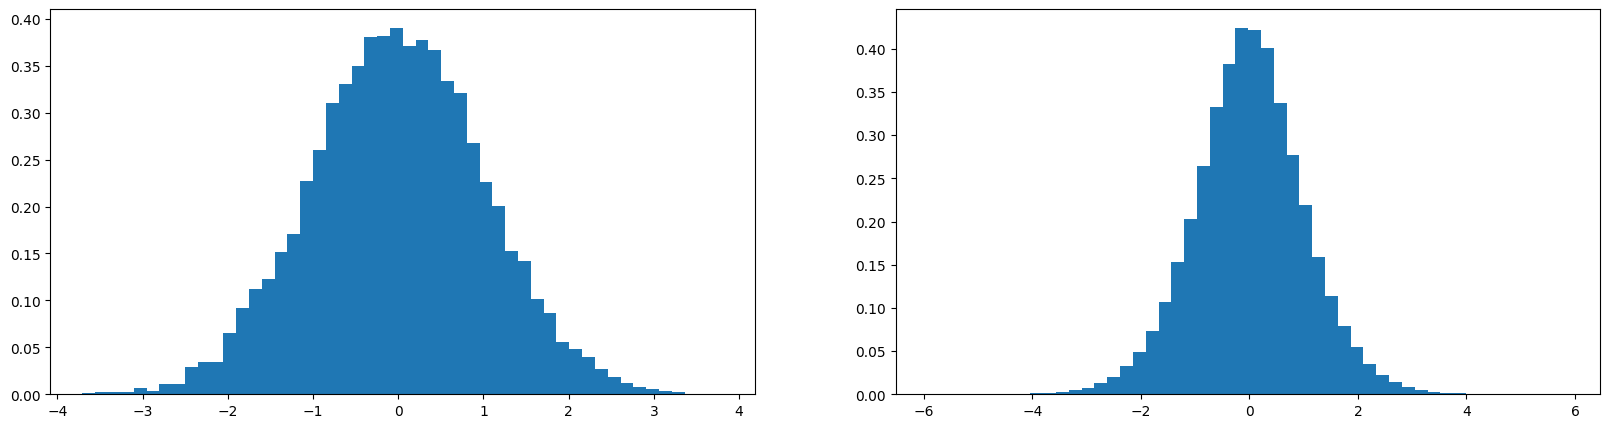

In [ ]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10 ** 0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

And look at that! Now y's standard deviation has been rescaled to 1.

And there are many other constants for various activation functions. If we really wanted to be accurate, we should have used a gain of 5/3 and divide that by the square root of the fan in for our tanh function. This turns out to be around 0.3, which isn't far from our guessed 0.2, and still gives us a good result given a principled guide.

In [ ]:
# Set up hyperparameters
vocab_size = len(chars) + 1
block_size = 3
n_embed = 11
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed)             , generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden) , generator=g) * (5/3)/((n_embed * block_size)**0.5)    # kaiming init
b1 = torch.randn((1, n_hidden)                    , generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size)           , generator=g) * 0.01
b2 = torch.randn((1, vocab_size)                  , generator=g) * 0
parameters = [C, W1, b1, W2, b2]

print(f"num parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

num parameters: 12524


In [ ]:
# Training
lossi = []
batch_size = 32
initial_lr = 0.1
iterations = 200000

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))

  # forward pass
  emb = C[Xtr[ix]]
  pre_h = emb.view((-1, n_embed * block_size)) @ W1 + b1
  h = torch.tanh(pre_h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = initial_lr if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # Note: Uncomment below if you'd like to visualize h below
  # break

      0/ 200000: 3.2864
  10000/ 200000: 2.3065
  20000/ 200000: 2.4958
  30000/ 200000: 1.8950
  40000/ 200000: 2.1686
  50000/ 200000: 1.9883
  60000/ 200000: 2.4556
  70000/ 200000: 2.2308
  80000/ 200000: 2.4150
  90000/ 200000: 1.8435
 100000/ 200000: 1.7200
 110000/ 200000: 2.0256
 120000/ 200000: 2.2535
 130000/ 200000: 2.3784
 140000/ 200000: 1.8942
 150000/ 200000: 1.8124
 160000/ 200000: 2.0255
 170000/ 200000: 2.1282
 180000/ 200000: 2.0117
 190000/ 200000: 2.0982


In [ ]:
split_loss('train')
split_loss('val')

train 2.033111810684204
val 2.1023221015930176


In [ ]:
# Sampling
g = torch.Generator().manual_seed(2147483647 + 10)

# generate 20 names
for _ in range(20):
  name = []
  context = [0] * block_size      # (1, 3)

  while True:
    # d = 11 (embedding feature size)
    emb = C[torch.tensor(context)]  # C: (27, d) -> emb: (block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    name.append(ix)
    if ix == 0:
      break

  print(''.join(itos[token] for token in name))


carmah.
amelle.
khy.
mili.
taty.
skaan.
kenlehnee.
deliah.
jareen.
nellara.
chaily.
kaleigh.
ham.
joce.
quinthonova.
alianni.
waterri.
jarynix.
kaelidgsan.
eddeli.


## Batch Normalization

While all those formulas are great, we have modern tools that can help us do this more consistently. The idea behind batch normalization is, well, if some matrix isn't Gaussian, can't we just normalize them to be Gaussian?

Previously we defined `pre_h` as a matrix that we'd like to inspect. That is the matrix we want to normalize. As described in the paper by [Ioffe and Szegedy 2015](https://arxiv.org/pdf/1502.03167), the formula for normalizing is

---

**Input**: Values over $x$ over a mini-batch: $\mathcal{B} = \{ x_1...m \};$

Parameters to be learned: $\mathcal{\gamma}, \beta$

**Output**: $\{ y_i = BN_{\mathcal{\gamma}, β} (x_i) \}$

$\mu_\mathcal{B} \leftarrow \frac{1}{m} \sum_{i=1}^m{x_i}$ // mini-batch mean

$\sigma^2_\mathcal{B} \leftarrow \frac{1}{m} \sum_{i=1}^m(x_i - \mu_\mathcal{B})$ // mini-batch variance

$\hat{x} \leftarrow \frac{x_i - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \epsilon}}$ // normalize

$y_i \leftarrow \gamma \hat{x_i} + \beta \equiv BN_{\mathcal{\gamma}, β} (x_i)$ // scale and shift

---

Basically, replace $x$ with `pre_h`. We get $\hat{x}$ by:
- Subtracting elementwise $x$ by its mean
- Then dividing that by the standard deviation (square root of variance = standard deviation) plus some epsilon.
  - The epsilon is there in case the variance is 0--we don't want to divide by 0. But in our case, that's unlikely to happen (probably more likely to happen in a larger model)

Then, we scale and shift by providing a batch normalization gain ($\gamma$) and a batch normalization bias ($\beta$). These will be learned parameters.

The scaling and shifting is due to the fact that we don't exactly always want the model to keep the distribution Gaussian and normalized. Instead, we want the model to be able to shift and move the distribution around so that neurons learn to have different weights. Intuitively, this allows the model to learn and decide where the best region of a function is for it to activate the neurons.

In [ ]:
# Set up hyperparameters
vocab_size = len(chars) + 1
block_size = 3
n_embed = 11
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed)             , generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden) , generator=g) * (5/3)/((n_embed * block_size)**0.5)    # kaiming init
b1 = torch.randn((1, n_hidden)                    , generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size)           , generator=g) * 0.01
b2 = torch.randn((1, vocab_size)                  , generator=g) * 0

# batch normalization parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(f"num parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

num parameters: 12924


In [ ]:
# Training
lossi = []
batch_size = 32
initial_lr = 0.1
iterations = 200000

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))

  # forward pass
  emb = C[Xtr[ix]]
  pre_h = emb.view((-1, n_embed * block_size)) @ W1 + b1

  # batch normalization
  mu = pre_h - pre_h.mean(0, keepdim=True)
  std = pre_h.std(0, keepdim=True)
  pre_h = bngain * mu / std + bnbias

  h = torch.tanh(pre_h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = initial_lr if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # Note: Uncomment below if you'd like to visualize h below
  # break

      0/ 200000: 3.2751
  10000/ 200000: 2.9975
  20000/ 200000: 2.2815
  30000/ 200000: 2.2743
  40000/ 200000: 2.1582
  50000/ 200000: 2.5098
  60000/ 200000: 2.3038
  70000/ 200000: 2.3806
  80000/ 200000: 2.1773
  90000/ 200000: 2.1749
 100000/ 200000: 2.1633
 110000/ 200000: 1.9440
 120000/ 200000: 2.1550
 130000/ 200000: 1.7938
 140000/ 200000: 2.3020
 150000/ 200000: 2.3248
 160000/ 200000: 2.2592
 170000/ 200000: 2.0794
 180000/ 200000: 2.2407
 190000/ 200000: 1.8892


Because we've batch normalized the pre-activations during training, we must follow a similar process during inference. However, because during training, the inputs are in batches, and obviously our inputs during training should not be in batches, what do we do?

The idea is to estimate the mean and standard deviation over the entire training dataset and use those as the estimates. We can do this two ways:

### 1. Do a separate estimation before inference

We can do an estimation of the mean and the standard deviation by running a loop through it once before inference.

In [ ]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1

  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

However, most people don't want to do another separate estimation before inference, so the paper also proposed another way:

### 2. Keeping Track of a Running Estimate
We can keep track of a running estimate during training and then use that result during inference, rather than having to compute it right before inference.

In [ ]:
# Set up hyperparameters
vocab_size = len(chars) + 1
block_size = 3
n_embed = 11
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed)             , generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden) , generator=g) * (5/3)/((n_embed * block_size)**0.5)    # kaiming init
b1 = torch.randn((1, n_hidden)                    , generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size)           , generator=g) * 0.01
b2 = torch.randn((1, vocab_size)                  , generator=g) * 0

# batch normalization parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

# the running variables
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(f"num parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

num parameters: 12924


In [ ]:
# Training
lossi = []
batch_size = 32
initial_lr = 0.1
iterations = 200000

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))

  # forward pass
  emb = C[Xtr[ix]]

  # for why b1 doesn't matter, see Extra Notes point 1 (below)
  pre_h = emb.view((-1, n_embed * block_size)) @ W1 # + b1

  # batch normalization
  mu = pre_h - pre_h.mean(0, keepdim=True)
  std = pre_h.std(0, keepdim=True)

  # these aren't supposed to be calculated with respect to gradients
  with torch.no_grad():
    # estimate the running mean and std
    bnmean_running = 0.999 * bnmean_running + 0.001 * mu
    bnstd_running = 0.999 * bnstd_running + 0.001 * std

  pre_h = bngain * mu / std + bnbias

  h = torch.tanh(pre_h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = initial_lr if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # Note: Uncomment below if you'd like to visualize h below
  # break

      0/ 200000: 3.2717
  10000/ 200000: 2.2508
  20000/ 200000: 2.4158
  30000/ 200000: 2.0077
  40000/ 200000: 2.0696
  50000/ 200000: 2.3156
  60000/ 200000: 2.7471
  70000/ 200000: 1.9971
  80000/ 200000: 2.2817
  90000/ 200000: 1.9671
 100000/ 200000: 2.4475
 110000/ 200000: 1.8981
 120000/ 200000: 2.1335
 130000/ 200000: 2.4603
 140000/ 200000: 2.0596
 150000/ 200000: 1.9949
 160000/ 200000: 2.0662
 170000/ 200000: 2.0284
 180000/ 200000: 1.9332
 190000/ 200000: 2.0729


In [ ]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'val': (Xval, Yval),
      'test': (Xte, Yte),
  }[split]
  emb = C[x]  # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)

  # for why b1 doesn't matter, see Extra Notes point 1 (below)
  pre_h = embcat @ W1 # + b1

  # batchnorm at test time too
  pre_h = bngain * (pre_h - bnmean_running) / bnstd_running + bnbias

  h = torch.tanh(pre_h)  # (N, n_hidden)
  logits = h @ W2 + b2  # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.063563585281372
val 2.108004093170166


## Some Notes About Batch Normalization

### The Good and the Bad
There seems to be both good and bad about batch normalization:
1. Couples batches of examples together (some don't like this property)
2. Though it does just work quite well
3. Acts as a regularizer as a side effect

Due to the mathematical properties of batch normalization, the `pre_h` batch trains the model with whatever examples that just happen to come along for the ride because they're sampled randomly (point 1). In other words, the logits are now no longer just a function of one single example at a time, but a batch of examples at a time. This means that each of the hidden states' activations are trained on the inputs that are now in batches, but that's not what we want most of the time.

This is good in a sense because it helps the model to not just focus on one specific example and capitalize on that; instead, it takes a whole normalized batch of examples which all have an impact on the parameters. This makes BatchNorm act like a regularizer (point 3), and is what makes it work quite well (point 2).

However, we don't like the property that the batch of examples are just coupled together because it can introduce a lot of bugs, so we're moving towards other techniques like Group Normalization and so on, but with difficulty because BatchNorm just works so well.

---

### Performance
Also, in terms of the loss/improvements on the model, we aren't really expecting too much of a performance boost. This is because we've already done some normalization at first on the individual weights and biases. However, in bigger neural nets, it's difficult to calculate all the individual scales those weights and biases should take on, so some form of a normalization is applied in the training code instead.

## Extra Notes!

### 1. b1 (bias) When Batch Normalizing

Previously when we had:

```python
pre_h = embcat @ W1 + b1
mu = pre_h.mean(0, keepdim=True)
# ...
pre_h = bngain * (pre_h - mu) / std + bnbias
```

Notice how while we add b1 to the h pre-activation, which is then taken into the mean calculation but also subtracted on that last line `pre_h - mu`. This makes it so that adding b1 does nothing. If we look at `b1.grad`, we'll see that it is actually 0, since it's removed after the fact.

Instead, we can remove it and the batch normalization has its own bias -- `bnbias`.

## Batch Normalization Layer Summary

The batch normalization layer helps to keep the weights nice and not so extreme, something we began to discover at the beginning of the notebook. We sprinkle this layer throughout, typically after some weight multiplication. While it can have its cons, like coupling examples together and thus requiring batches of inputs to be sent for inference, we can remediate that by keeping a running sum.

A really common pattern we'll notice is that layers are typically stacked in this order:

1. Linear layer (like just weight matrix multiplication)
2. Norm Layer (like BatchNorm)
3. Nonlinear layer (like tanh, ReLU, etc.)

I put the split_loss function here for convenience:

In [ ]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'val': (Xval, Yval),
      'test': (Xte, Yte),
  }[split]
  emb = C[x]  # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)

  # for why b1 doesn't matter, see Extra Notes point 1 (below)
  pre_h = embcat @ W1 # + b1

  # batchnorm at test time too
  pre_h = bngain * (pre_h - bnmean_running) / bnstd_running + bnbias

  h = torch.tanh(pre_h)  # (N, n_hidden)
  logits = h @ W2 + b2  # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

## PyTorch-ifying Our Model!

In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5   # kaiming init
    self.bias = torch.zeros((1, fan_out)) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])


class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum

    # flags if you're using this for training or inference
    self.training = True

    # batch normalization parameters
    self.gamma = torch.ones((1, dim))
    self.beta = torch.zeros((1, dim))

    # buffers
    self.running_mean = torch.zeros((1, dim))
    self.running_var = torch.ones((1, dim))

  def __call__(self, x):
    # mean and variance
    xmean, xvar = 0, 0

    if self.training:
      xmean = x.mean(0, keepdims=True)  # batch mean
      xvar = x.var(0, keepdims=True)    # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var

    # normalize to unit variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

    # self.out here to be able to plot them more easily later, but
    # not conventional to PyTorch
    self.out = self.gamma * xhat + self.beta

    # update the buffers
    if self.training:
      # tells PyTorch to not maintain computational graphs behind the scenes
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [ ]:
# the dimensionality of the character embedding vectors
n_embd = 10

# the number of neurons in the hidden layer
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size),
]

with torch.no_grad():
  # make last layer less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

46497


By the way, the reason why we have these Tanh layers in between is because 1) if we don't have them, then the whole model just collapses into one huge linear layer (during the forward pass and 2) during the backward pass, strange things happen due to chain rule being applied on multiple linear transformations (there are papers that talk about this).

Tanh functions allows this neural net to approximate any arbitrary function. In general, implementing nonlinear functions allows a function to approximate any number of nonlinear functions. This is a math property.

In [ ]:
# Training
iterations = 200000
batch_size = 32
lossi = []
ud = []

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

  # the batches
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]
  x = emb.view((emb.shape[0], -1))
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # logits are from the last x

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  with torch.no_grad():
    ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

  # Note: Uncomment below if you'd like to visualize h below
  if i > 1000:
    break

      0/ 200000: 3.2962


## Visualizations

### 1. Visualizing all the tanh outputs

layer 1 (      Tanh): mean -0.02, std 0.75, saturated: 20.25%
layer 3 (      Tanh): mean -0.00, std 0.69, saturated: 8.38%
layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 6.62%
layer 7 (      Tanh): mean -0.01, std 0.66, saturated: 5.47%
layer 9 (      Tanh): mean -0.02, std 0.66, saturated: 6.12%


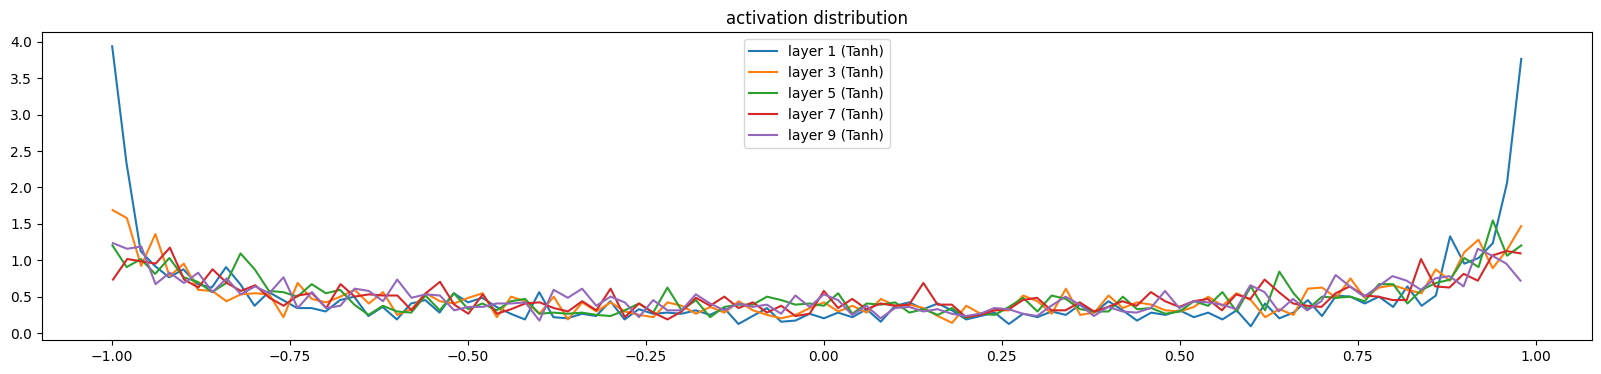

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out

    # saturation is how much the neurons' activations are at the extremes (-1, 1)
    # we don't want it to be too high
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%'
    % (i,
       layer.__class__.__name__,
       t.mean(),
       t.std(),
       (t.abs() > 0.97).float().mean()*100))

    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('activation distribution')

We see that the graph above shows the first layer being relatively more saturated than the later layers. The standard deviation remains at a nice 0.66ish and everything stabilizes.

```
layer 1 (      Tanh): mean -0.02, std 0.75, saturated: 20.25%
layer 3 (      Tanh): mean -0.00, std 0.69, saturated: 8.38%
layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 6.62%
layer 7 (      Tanh): mean -0.01, std 0.66, saturated: 5.47%
layer 9 (      Tanh): mean -0.02, std 0.66, saturated: 6.12%
```

However, if we were to change the gain from 5/3 to 1, then we'll see the following:

```
layer 1 (      Tanh): mean -0.02, std 0.62, saturated: 3.50%
layer 3 (      Tanh): mean -0.00, std 0.48, saturated: 0.03%
layer 5 (      Tanh): mean +0.00, std 0.41, saturated: 0.06%
layer 7 (      Tanh): mean +0.00, std 0.35, saturated: 0.00%
layer 9 (      Tanh): mean -0.02, std 0.32, saturated: 0.00%
```

This is because after each linear layer, there is a tanh layer. The tanh layer shrinks the distributions down between -1 to 1. And if we keep the gain at 1 (along with the linear layer dividing by `fan_in ** 0.5`), then the distribution would keep shrinking and shrinking. Previously, dividing by `fan_in ** 0.5` helped to keep our standard deviation to 1 (so that it's not scaling up and up), but now we have an opposite problem--we keep shrinking the distribution every time we run through the linear layer. So, the 5/3 is meant to scale the distribution back up to fight the shrinkage.

### 2. Visualizing the tanh's gradients

layer 1 (      Tanh): mean +0.000000, std 1.892402e-05
layer 3 (      Tanh): mean -0.000001, std 3.943546e-05
layer 5 (      Tanh): mean +0.000004, std 8.035369e-05
layer 7 (      Tanh): mean +0.000009, std 1.561152e-04
layer 9 (      Tanh): mean -0.000014, std 3.053498e-04


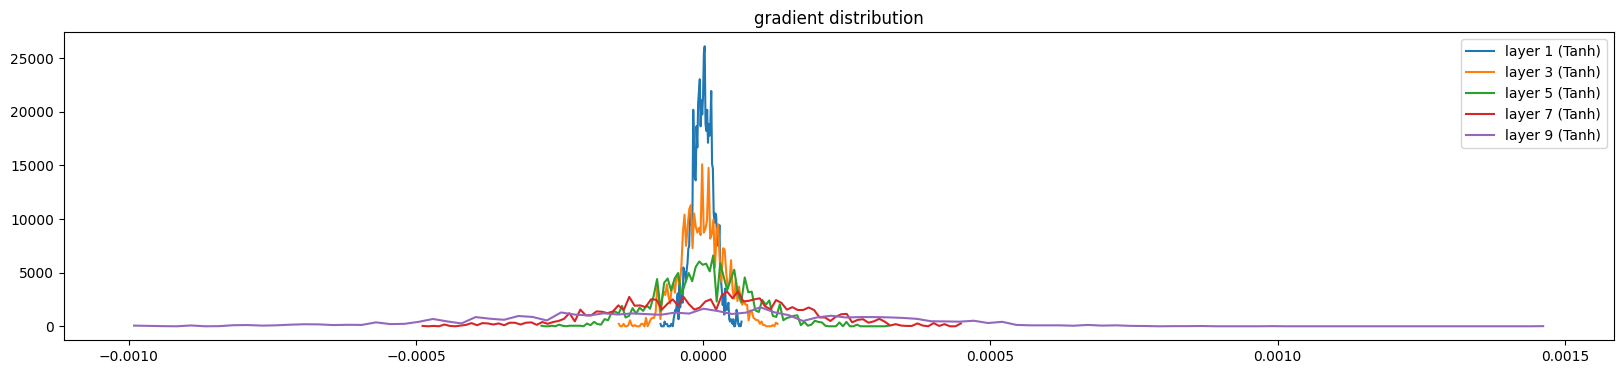

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad

    # saturation is how much the neurons' activations are at the extremes (-1, 1)
    # we don't want it to be too high
    print('layer %d (%10s): mean %+f, std %e'
    % (i,
       layer.__class__.__name__,
       t.mean(),
       t.std()))

    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('gradient distribution')

What we're looking for here is that all the gradient curves are fairly similar. If we were to change the gain value from 5/3 to something like 1, 0.5, or 3 (too high), then we will see that the gradients of the later layers begin to diverge and the curves begin to expand. Above is an example of a bad curve as the gradients spread out further and further (having set the gain to 0.5 instead of 5/3).

Additionally, if we were to just have linear layers, then our gain would have to be set to 1 above, instead of 5/3.

### 3. Visualizing Weights Gradient Distribution



Here, the gradient to data ratio represents the scale of the gradients relative to their data. This is important because at each step we take, we don't want the gradient to be too big, to the point where they overstep. Typically, a ratio of 1e-03 to 1 is a good ratio.

weight   (27, 10) | mean -0.000031 | std 1.365078e-03 | grad:data ratio 1.364090e-03
weight  (30, 100) | mean -0.000049 | std 1.207430e-03 | grad:data ratio 3.871660e-03
weight (100, 100) | mean +0.000016 | std 1.096730e-03 | grad:data ratio 6.601988e-03
weight (100, 100) | mean -0.000010 | std 9.893572e-04 | grad:data ratio 5.893091e-03
weight (100, 100) | mean -0.000011 | std 8.623432e-04 | grad:data ratio 5.158124e-03
weight (100, 100) | mean -0.000004 | std 7.388576e-04 | grad:data ratio 4.415211e-03
weight  (100, 27) | mean -0.000000 | std 2.364824e-02 | grad:data ratio 2.328203e+00


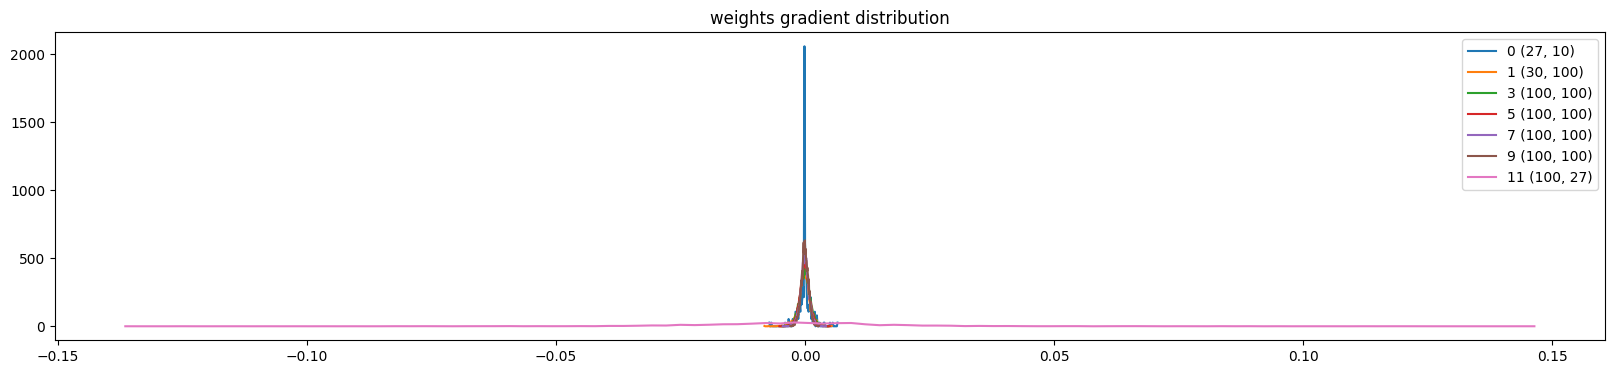

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
  t = p.grad

  # only restrict to 2 dimensions
  if p.ndim == 2 and p.shape[0] != 1:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (
      tuple(p.shape),
      t.mean(),
      t.std(),
      t.std() / p.std()
    ))

    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends);
plt.title('weights gradient distribution')

The distribution above is when the gain is 5/3 (which is normal). Notice how all the other ratios are concentrated around 1e-03 (1000 times smaller), which is good.

The pink, which is the last layer, has the ratios spread anywhere from nea -0.15 to 0.15, which is quite big. This means the last layer would be training way faster than the other layers since it takes much bigger steps.

While this problem will fix itself the more passes it trains for, it's still a little troubling for other optimizers like Adam. The following graph is after training the model for 1000 iterations, and you can see that the pink (last) layer is acting less deviant:

weight   (27, 10) | mean +0.001421 | std 1.328779e-02 | grad:data ratio 1.319907e-02
weight  (30, 100) | mean -0.000079 | std 1.081848e-02 | grad:data ratio 3.409258e-02
weight (100, 100) | mean -0.000177 | std 8.011200e-03 | grad:data ratio 4.634176e-02
weight (100, 100) | mean -0.000025 | std 7.252831e-03 | grad:data ratio 4.182952e-02
weight (100, 100) | mean +0.000005 | std 7.640808e-03 | grad:data ratio 4.430979e-02
weight (100, 100) | mean +0.000109 | std 7.125474e-03 | grad:data ratio 4.195732e-02
weight  (100, 27) | mean -0.000000 | std 2.339034e-02 | grad:data ratio 2.619864e-01


Text(0.5, 1.0, 'weights gradient distribution')

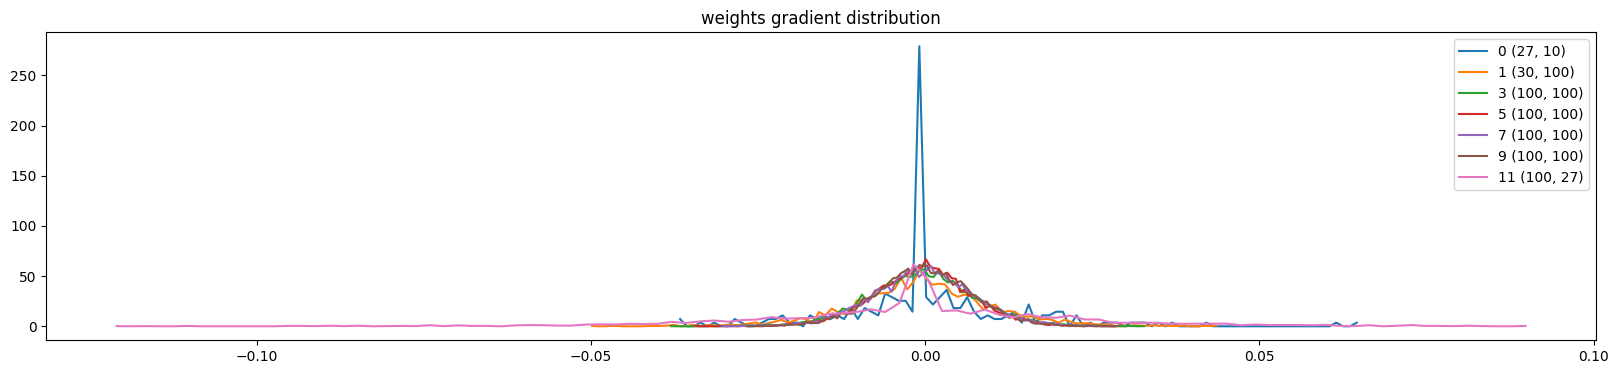

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
  t = p.grad

  # only restrict to 2 dimensions
  if p.ndim == 2 and p.shape[0] != 1:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (
      tuple(p.shape),
      t.mean(),
      t.std(),
      t.std() / p.std()
    ))

    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends);
plt.title('weights gradient distribution')

However, the more important thing than the gradient to data ratio is the update to the gradient to data ratio, because that's the amount of change that will be applied to these tensors.

### 4. Visualizing Update to Data Ratios

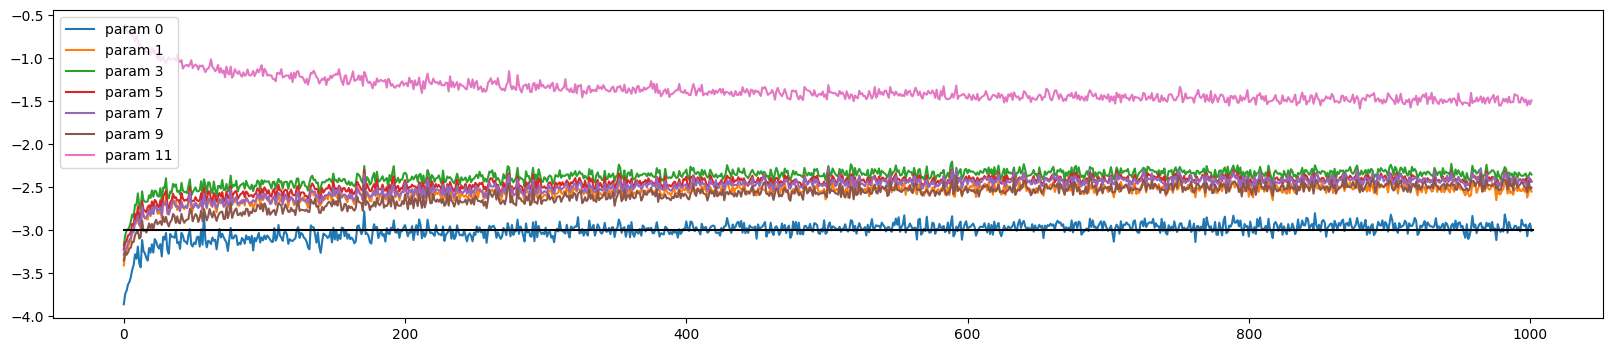

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
  # only restrict to weights
  if p.ndim == 2 and p.shape[0] != 1:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

We see that the update to data ratio converges, or stabilizes over time, which is good. The pink curve, again the last layer, is an outlier because it is artificially squashed to have a nice distribution of weights. The black line is the ideal or guiding ratio that we'd want. We don't want the ratio to be too far above the line.

The learning rate dictates how fast these ratios converge. If the learning rate is too small, then the ratios will converge rather slowly. The graph below shows what happens when the learning rate is 0.001 (as opposed to 0.1):

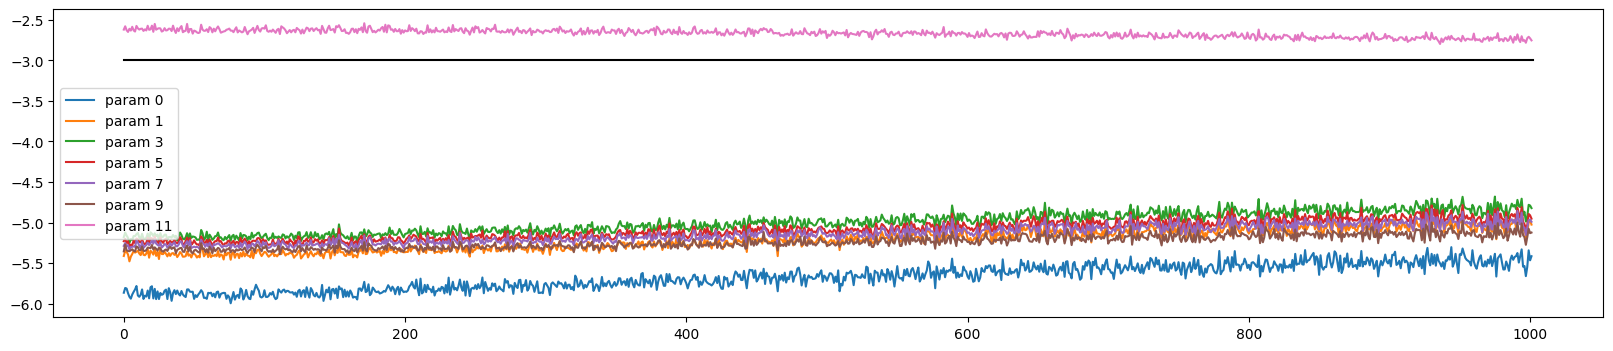

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
  # only restrict to weights
  if p.ndim == 2 and p.shape[0] != 1:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Using The BatchNorm1D Layer

Now, all of what we've been doing, like setting the ratios, the gain, and everything, still feels like you're trying to achieve a really impossible balance.

To help fix this issue more easily, we can bring the BatchNorm1D layer back in.

In [ ]:
# the dimensionality of the character embedding vectors
n_embd = 10

# the number of neurons in the hidden layer
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
  # make last layer less confident
  layers[-1].gamma *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

47551


In [ ]:
# Training
iterations = 200000
batch_size = 32
lossi = []
ud = []

for i in range(iterations):
  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

  # the batches
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]
  x = emb.view((emb.shape[0], -1))
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # logits are from the last x

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{iterations:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  with torch.no_grad():
    ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

  # Note: Uncomment below if you'd like to visualize h below
  if i > 1000:
    break

      0/ 200000: 3.2870


We can then re-visualize the tanh layers, which will have a very good distribution:


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.97%
layer 5 (      Tanh): mean +0.01, std 0.64, saturated: 2.41%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.44%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.22%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%


Text(0.5, 1.0, 'activation distribution')

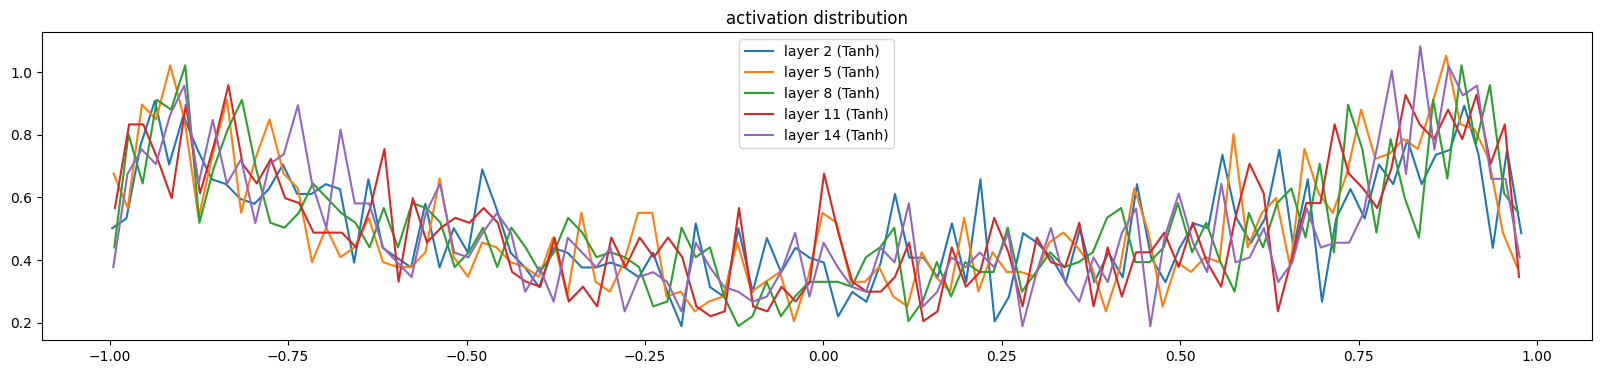

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out

    # saturation is how much the neurons' activations are at the extremes (-1, 1)
    # we don't want it to be too high
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%'
    % (i,
       layer.__class__.__name__,
       t.mean(),
       t.std(),
       (t.abs() > 0.97).float().mean()*100))

    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('activation distribution')

Now, the gain and the fan_in won't affect the distributions as much anymore, but the updates to the gradient to data ratio will change. So if you're changing the gain, then you'll probably also have to change the learning rate.